In [1]:
!python --version
import os
import warnings
print (os.environ['CONDA_DEFAULT_ENV'])

#suppress warnings
warnings.filterwarnings('ignore')



Python 3.7.12
culRIBayes


# 1. Workbook setups

## 1.1 Import packages

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
import math
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import statsmodels.api as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot

from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time

## 1.2 Miscellaneous codes

In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

## 1.3 Dictionaries

In [4]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


## 1.4 Set local paths

In [5]:
# set the path to local folder other than github
login_name = os.getlogin()

### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'

# 2. Import data

## 2.1 Culture Compilation

In [6]:
fpath = os.path.join(local_github_path,'spreadsheets')
fname = r'revised_cultures_GDGT_github_March2025_RR.xlsx'

culture_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='master_cultures')
culture_df['TEX86'] = np.sum(culture_df[['fGDGT_2', 'fGDGT_3', 'fGDGT_cren_prime']],axis=1)/np.sum(culture_df[['fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren_prime']],axis=1)

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
culture_df['ringIndex'] = np.array([culture_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
culture_df['scaledRI'] = culture_df['ringIndex']/4
culture_df['gdgt23ratio'] = culture_df['fGDGT_2']/culture_df['fGDGT_3']
culture_df['methaneIndex'] = culture_df[['fGDGT_1', 'fGDGT_2', 'fGDGT_3']].sum(axis=1)/culture_df[['fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']].sum(axis=1)
culture_df['gdgtZeroOverZeroCren'] = (culture_df['fGDGT_0']/culture_df[['fGDGT_0','fGDGT_cren']].sum(axis=1))


#### copy culture_df to culture_df2 to keep the original df
culture_df2 = culture_df.dropna(how='any', subset=['TEX86']).reset_index(drop=True)
culture_df2['methaneIndex']= culture_df2['methaneIndex'].fillna(-999)
culture_df2['gdgtZeroOverZeroCren'] = culture_df2['fGDGT_0'].fillna(-999)

culture_df2['TEX_RI'] = (-0.77*culture_df2['TEX86']
                                )+(3.32*culture_df2['TEX86']**2
                                   )+(1.59)
culture_df2['deltaRI'] = culture_df2['TEX_RI']-culture_df2['ringIndex']

culture_df2

,sampleName,Strains,organism_reported_names,phyloT_order,GTDB_phylum,GTDB_class,GTDB_order,GTDB_family,GTDB_genus,GTDB_species,...,DOI,Taxonomy data update,TEX86,ringIndex,scaledRI,gdgt23ratio,methaneIndex,gdgtZeroOverZeroCren,TEX_RI,deltaRI
0,Bale2019_001_Cultures_ThAOA_Ca_Nitrosotenuis u...,N4,Ca. Nitrosotenuis uzonensis N4,13.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosotenuis,NaN,...,https://doi.org/10.1128/AEM.01332-19,GTDB Release 214.1; NCBI (retrieved from Febru...,0.928571,3.000000,0.750000,0.560000,0.677419,0.000000,3.737653,0.737653
1,Bale2019_002_Cultures_ThAOA_Ca_Nitrosotenuis u...,N4,Ca. Nitrosotenuis uzonensis N4,13.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosotenuis,NaN,...,https://doi.org/10.1128/AEM.01332-19,GTDB Release 214.1; NCBI (retrieved from Febru...,0.955224,3.480226,0.870056,0.422222,0.378531,0.000000,3.883820,0.403594
2,Bale2019_003_Cultures_ThAOA_Ca_Nitrosotenuis u...,N4,Ca. Nitrosotenuis uzonensis N4,13.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosotenuis,NaN,...,https://doi.org/10.1128/AEM.01332-19,GTDB Release 214.1; NCBI (retrieved from Febru...,0.988372,3.486726,0.871681,0.491228,0.380531,0.000000,4.072193,0.585467
3,Bale2019_004_Cultures_ThAOA_Ca_Nitrosotenuis u...,N4,Ca. Nitrosotenuis uzonensis N4,13.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosotenuis,NaN,...,https://doi.org/10.1128/AEM.01332-19,GTDB Release 214.1; NCBI (retrieved from Febru...,0.378378,2.184358,0.546089,2.111111,0.513889,0.195531,1.773974,-0.410384
4,Bale2019_005_Cultures_ThAOA_Ca_Nitrosotenuis u...,N4,Ca. Nitrosotenuis uzonensis N4,13.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosotenuis,NaN,...,https://doi.org/10.1128/AEM.01332-19,GTDB Release 214.1; NCBI (retrieved from Febru...,0.600000,3.686747,0.921687,1.625000,0.107692,0.021084,2.323200,-1.363547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,Elling_etal_unpubl_Nmaritimus_SCM1_28-2_CR15,SCM1,Nitrosopumilus maritimus SCM1,7.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosopumilus,s__Nitrosopumilus maritimus,...,Unpublished dataset,Unpublished dataset,0.686003,2.651623,0.662906,4.152970,0.393685,0.155288,2.624169,-0.027454
202,Elling_etal_unpubl_Nmaritimus_SCM1_28-3_CR16,SCM1,Nitrosopumilus maritimus SCM1,7.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosopumilus,s__Nitrosopumilus maritimus,...,Unpublished dataset,Unpublished dataset,0.667589,2.630964,0.657741,4.239946,0.390421,0.161022,2.555597,-0.075367
203,Elling_etal_unpubl_Nmaritimus_SCM1_32-1_CR17,SCM1,Nitrosopumilus maritimus SCM1,7.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosopumilus,s__Nitrosopumilus maritimus,...,Unpublished dataset,Unpublished dataset,0.778790,2.998250,0.749562,4.437900,0.338664,0.089802,3.003956,0.005706
204,Elling_etal_unpubl_Nmaritimus_SCM1_32-2_CR18,SCM1,Nitrosopumilus maritimus SCM1,7.0,p__Thermoproteota,c__Nitrososphaeria,o__Nitrososphaerales,f__Nitrosopumilaceae,g__Nitrosopumilus,s__Nitrosopumilus maritimus,...,Unpublished dataset,Unpublished dataset,0.705434,3.037094,0.759274,3.404992,0.264283,0.115226,2.698970,-0.338124


Text(30.2, 2.9, 'Ion Trap-MS\n(Schouten07)\n[cf. Hopmans2000]')

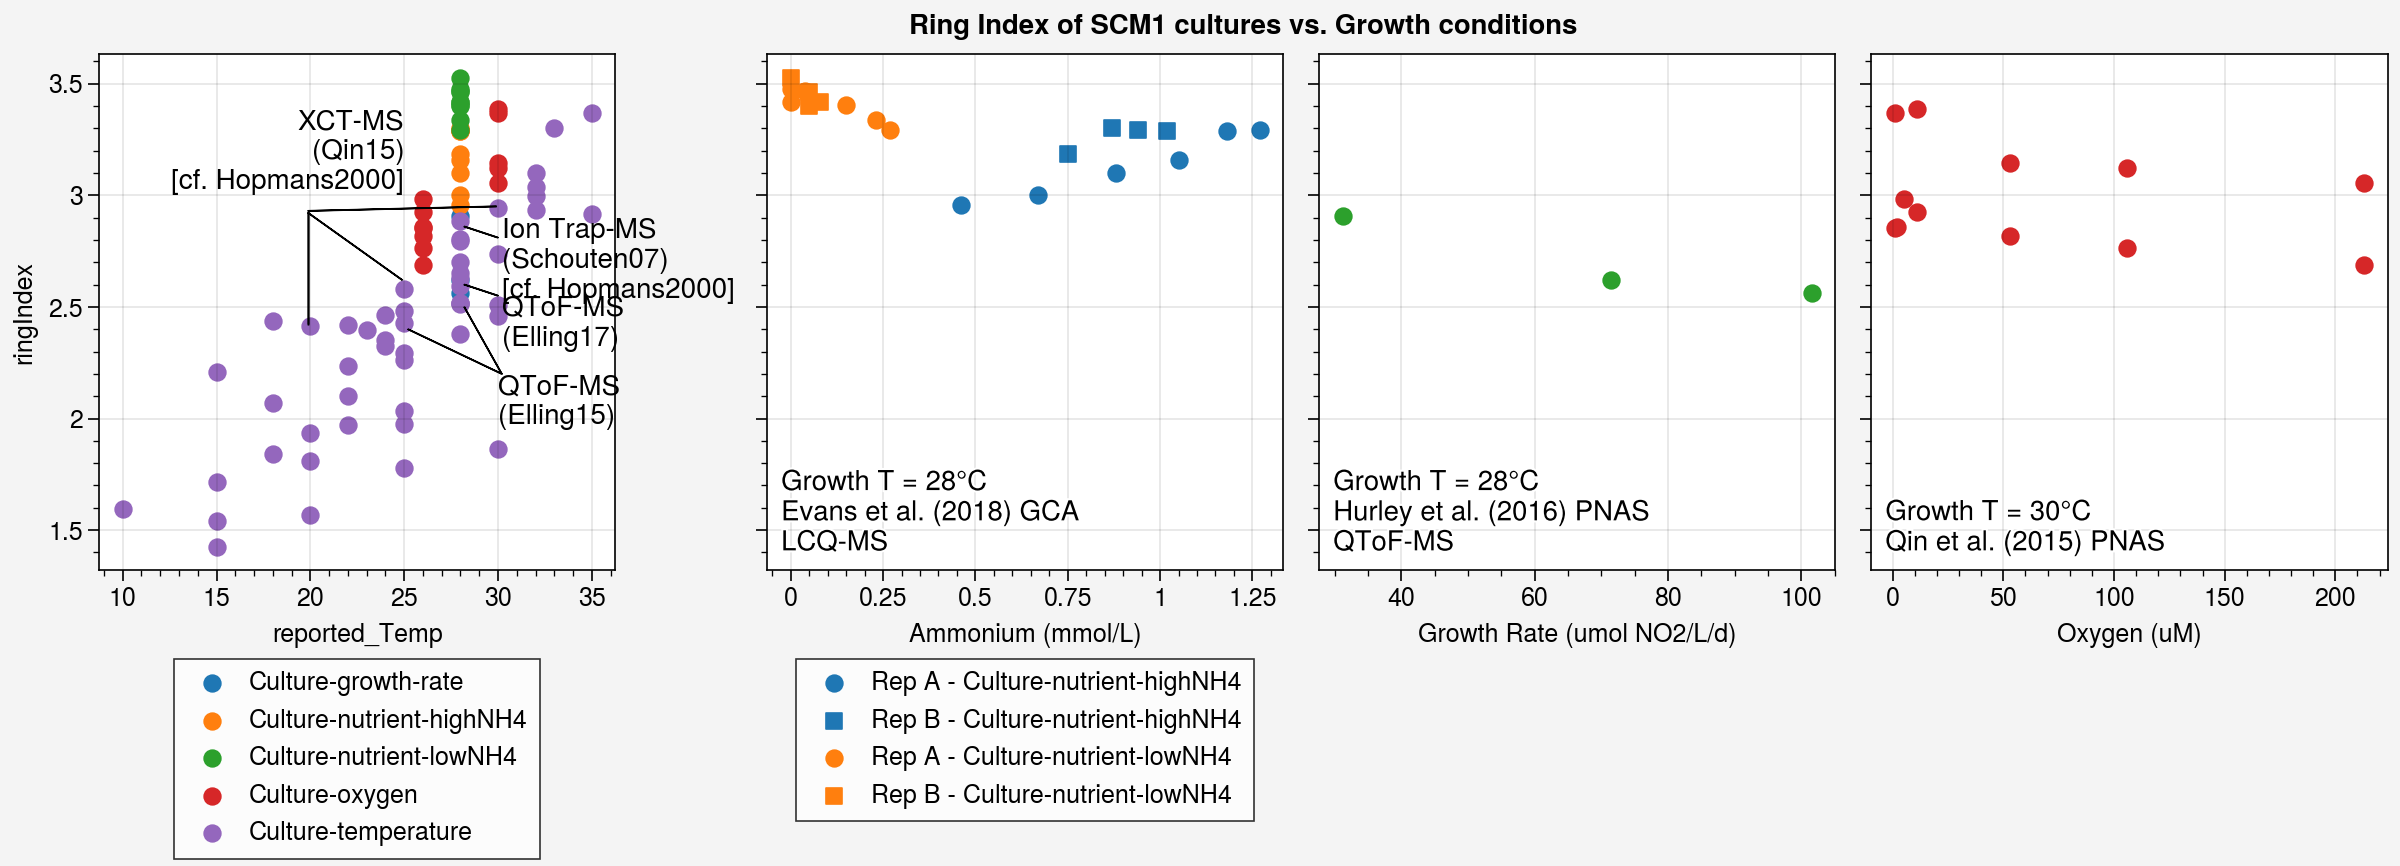

In [7]:
fig, axs = plot.subplots(width=12,ncols=4,sharex=0)
plot_data = culture_df2[culture_df2['GTDB_family'] == 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data = plot_data[plot_data['Source']!='Varma et al. (2024) Biogeosciences']
plot_data = plot_data[plot_data['GTDB_genus']=='g__Nitrosopumilus']
grouped = plot_data.groupby('experiment_setup')
for key, group in grouped:
    axs[0].scatter(group['reported_Temp'],group['ringIndex'],
                   cycle='tab10',
                   label=key,marker='o')
    
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h,l,ncol=1,loc='b',fontsize=10)

plot_data2 = plot_data[plot_data['experiment_setup'].isin(['Culture-nutrient-highNH4','Culture-nutrient-lowNH4'])]
grouped2 = plot_data2.groupby('experiment_setup')
colors = ['tab:blue','tab:orange']
for ii, (key, group) in enumerate(grouped2):
    for i in range(len(group)):
        if 'repA' in group['sampleName'].iloc[i]:
            axs[1].scatter(group['reported_ammonium'].iloc[i],group['ringIndex'].iloc[i],
                    c=colors[ii],
                    label=f'Rep A - {key}',marker='o')
        else:
            axs[1].scatter(group['reported_ammonium'].iloc[i],group['ringIndex'].iloc[i],
                    c=colors[ii],
                    label=f'Rep B - {key}',
                    marker='s')
axs[1].format(xlabel='Ammonium (mmol/L)',
              lltitle='Growth T = 28$\degree$C\nEvans et al. (2018) GCA\nLCQ-MS',)
h, l = axs[1].get_legend_handles_labels()
axs[1].legend([h[i] for i in [0,6,10,-1]],
              [l[i] for i in [0,6,10,-1]],ncol=1,loc='b',fontsize=10)

plot_data3 = plot_data[plot_data['experiment_setup'].isin(['Culture-growth-rate'])]
axs[2].scatter(plot_data3['reported_AOR_umol_NO2_l_d'],plot_data3['ringIndex'],
               c='tab:green',label='Growth Rate',marker='o')
axs[2].format(xlabel='Growth Rate (umol NO2/L/d)',
              lltitle='Growth T = 28$\degree$C\nHurley et al. (2016) PNAS\nQToF-MS',)

plot_data4 = plot_data[plot_data['experiment_setup'].isin(['Culture-oxygen'])]
axs[3].scatter(plot_data4['reported_oxy_micromolar'],plot_data4['ringIndex'],
               c='tab:red',label='Oxygen',marker='o')
axs[3].format(xlabel='Oxygen (uM)',
              lltitle='Growth T = 30$\degree$C\nQin et al. (2015) PNAS',)
axs.format(
    suptitle='Ring Index of SCM1 cultures vs. Growth conditions',
)

# Add arrows and text annotations
axs[0].arrow(25.2, 2.4, 5, -0.2, fc='black', ec='black')
axs[0].arrow(28.2, 2.5, 2, -0.3, fc='black', ec='black')
axs[0].text(30, 2.2, 'QToF-MS\n(Elling15)', fontsize=10, color='black',
            ha='left',va='top')

axs[0].arrow(28.2, 2.6, 1.8, -0.05, fc='black', ec='black')
axs[0].text(30.2, 2.55, 'QToF-MS\n(Elling17)', fontsize=10, color='black',
            ha='left',va='top')

axs[0].arrow(19.9, 2.42, 0, 0.5, fc='black', ec='black')
axs[0].arrow(24.9, 2.62, -5, 0.3, fc='black', ec='black')
axs[0].arrow(29.9, 2.95, -10, -0.02, fc='black', ec='black')
axs[0].text(25, 3, 'XCT-MS\n(Qin15)\n[cf. Hopmans2000]', fontsize=10, color='black',
            ha='right',va='bottom')

axs[0].arrow(28.2, 2.86, 1.8, -0.05, fc='black', ec='black')
axs[0].text(30.2, 2.9, 'Ion Trap-MS\n(Schouten07)\n[cf. Hopmans2000]', fontsize=10, color='black',
            ha='left',va='top')

In [8]:
culture_df2.columns

Index(['sampleName', 'Strains', 'organism_reported_names', 'phyloT_order',
       'GTDB_phylum', 'GTDB_class', 'GTDB_order', 'GTDB_family', 'GTDB_genus',
       'GTDB_species', 'NCBI_phylum', 'NCBI_class', 'NCBI_order',
       'NCBI_family', 'NCBI_genus', 'NCBI_species', 'organism_broadClass',
       'organism_broadClass2', 'organism_broadClass3',
       'organism_genomes_combined_WGS_PGS', 'isolate_from',
       'geographic_location', 'sampleID_new', 'reported_Temp',
       'reported_Salinity', 'reported_pH', 'reported_oxy_micromolar',
       'reported_ammonium', 'reported_ionicStrength',
       'reported_AOR_umol_NO2_l_d', 'reported_growthPhase_growthRate',
       'experiment_setup', 'Broad Filtration Class', 'Lipid Extractions',
       'Filter pore size', 'LCMS_instrumentation', 'sum_reported_fractions',
       'reported_1302', 'reported_1300', 'reported_1298', 'reported_1296',
       'reported_1292', 'reported_1292_iso', 'reported_1294', 'reported_1290',
       'reported_1288', 're

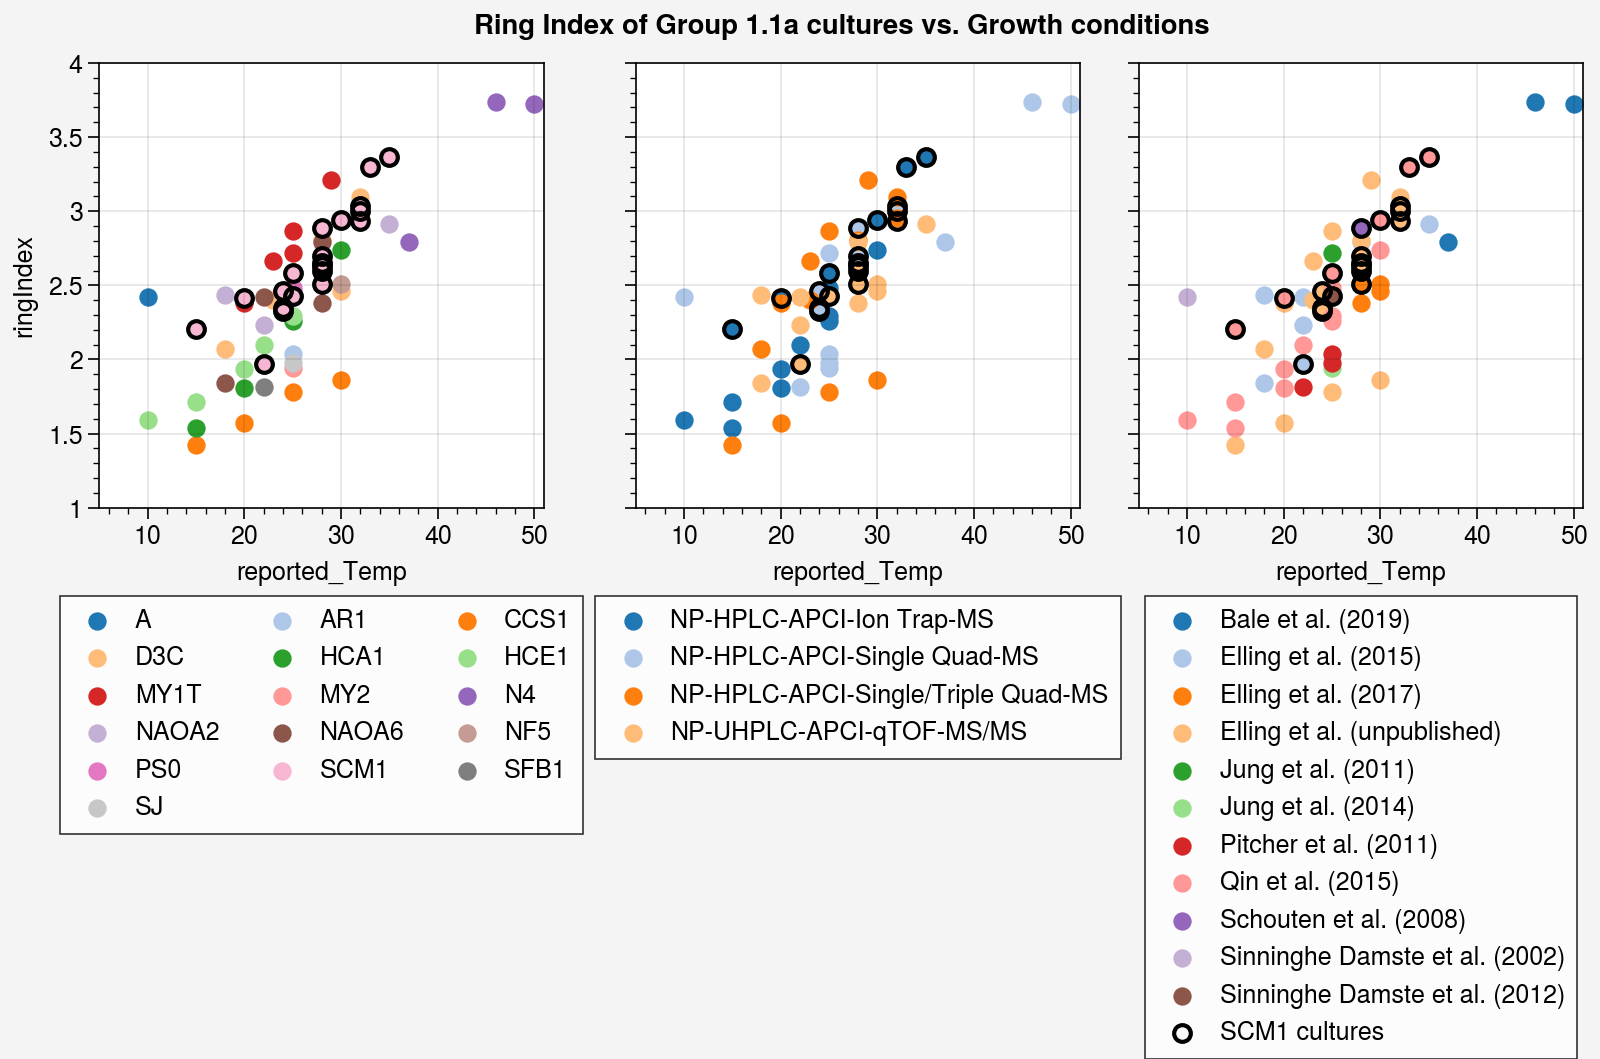

In [9]:

plot_data = culture_df2[culture_df2['GTDB_family'] == 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data = plot_data[plot_data['Source']!='Varma et al. (2024) Biogeosciences']
plot_data = plot_data[plot_data['experiment_setup']=='Culture-temperature']
plot_data2 = plot_data[plot_data['Strains']=='SCM1']
chart_label_name = 'Group 1.1a'

plot_data = plot_data[plot_data['organism_broadClass2']==chart_label_name]
# plot_data = plot_data[plot_data['Strains']==chart_label_name]
# plot_label_name = plot_data['organism_reported_names'].iloc[0]
plot_label_name = 'Group 1.1a'
fig, axs = plot.subplots(width=8,ncols=3,sharex=0)

axs.format(
    suptitle=f'Ring Index of {plot_label_name} cultures vs. Growth conditions',
)


grouped = plot_data.groupby('Strains')
for key, group in grouped:
    axs[0].scatter(group['reported_Temp'],group['ringIndex'],
                   cycle='tab20',
                   label=key,marker='o')
    
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h,l,ncol=3,loc='b',fontsize=10)

grouped = plot_data.groupby('LCMS_instrumentation')
for key, group in grouped:
    axs[1].scatter(group['reported_Temp'],group['ringIndex'],
                   cycle='tab20',
                   label=key,marker='o')
    
h, l = axs[1].get_legend_handles_labels()
axs[1].legend(h,l,ncol=1,loc='b',fontsize=10)

grouped = plot_data.groupby('Source2')
for key, group in grouped:
    axs[2].scatter(group['reported_Temp'],group['ringIndex'],
                   cycle='tab20',
                   label=key,marker='o')

axs.scatter(plot_data2['reported_Temp'],plot_data2['ringIndex'],
            c='none',edgecolor='black',marker='o',linewidth=1.5,zorder=10,
            label='SCM1 cultures')
h, l = axs[2].get_legend_handles_labels()
axs[2].legend(h,l,ncol=1,loc='b',fontsize=10)

axs.format(
    ylim=(1,4),
    xlim=(5,51),
)


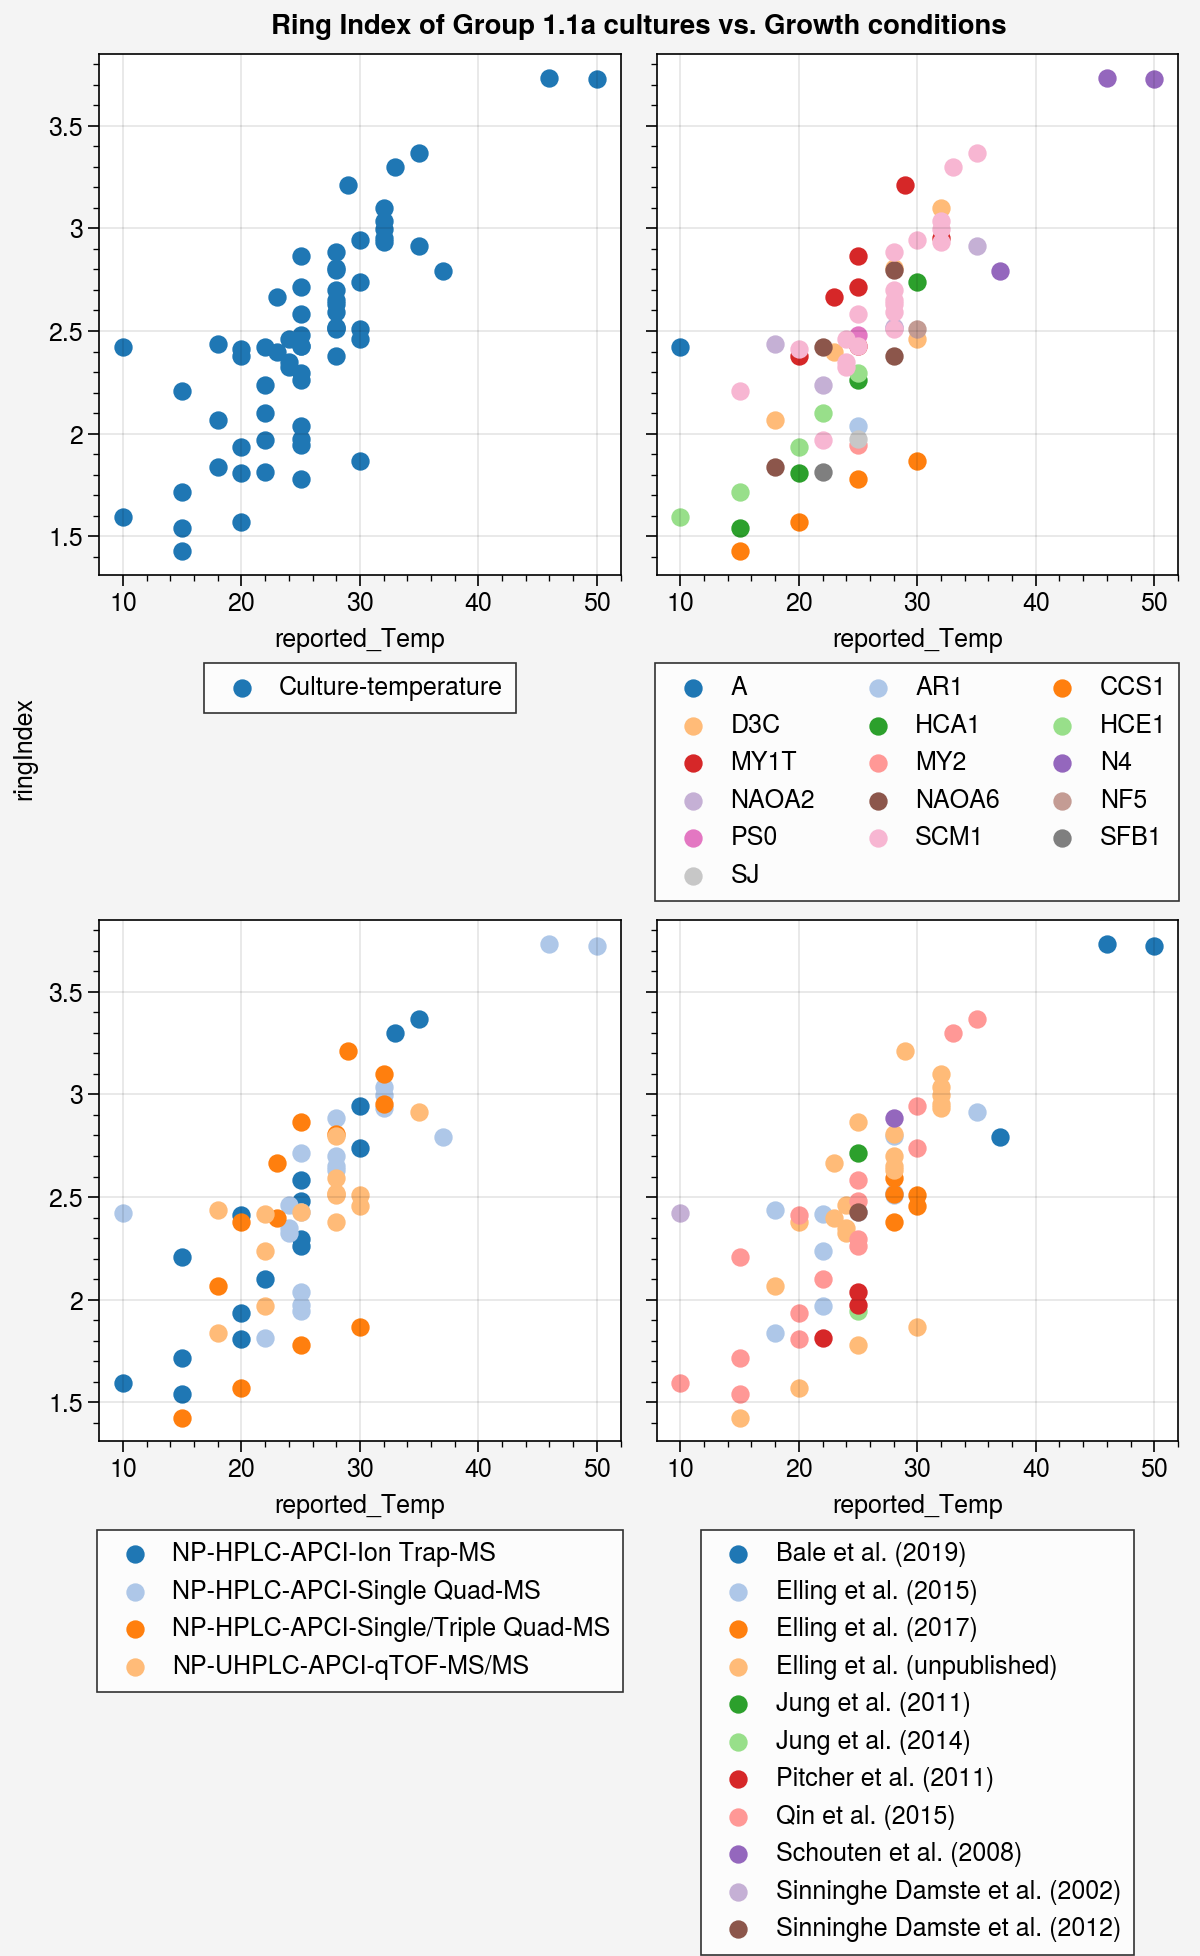

In [10]:

plot_data = culture_df2[culture_df2['GTDB_family'] == 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data = plot_data[plot_data['Source']!='Varma et al. (2024) Biogeosciences']
plot_data = plot_data[plot_data['experiment_setup']=='Culture-temperature']
plot_data2 = plot_data[plot_data['Strains']=='SCM1']
chart_label_name = 'Group 1.1a'
plot_data = plot_data[plot_data['organism_broadClass2']==chart_label_name]
# plot_data = plot_data[plot_data['Strains']==chart_label_name]


fig, axs = plot.subplots(width=6,ncols=2,nrows=2,sharex=0)
grouped = plot_data.groupby('experiment_setup')
for key, group in grouped:
    axs[0].scatter(group['reported_Temp'],group['ringIndex'],
                   cycle='tab10',
                   label=key,marker='o')


    
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h,l,ncol=1,loc='b',fontsize=10)


axs.format(
    suptitle=f'Ring Index of {chart_label_name} cultures vs. Growth conditions',
)


# Add arrows and text annotations
# axs[0].arrow(25.2, 2.4, 5, -0.2, fc='black', ec='black')
# axs[0].arrow(28.2, 2.5, 2, -0.3, fc='black', ec='black')
# axs[0].text(30, 2.2, 'QToF-MS\n(Elling15)', fontsize=10, color='black',
#             ha='left',va='top')

# axs[0].arrow(28.2, 2.6, 1.8, -0.05, fc='black', ec='black')
# axs[0].text(30.2, 2.55, 'QToF-MS\n(Elling17)', fontsize=10, color='black',
#             ha='left',va='top')

# axs[0].arrow(19.9, 2.42, 0, 0.5, fc='black', ec='black')
# axs[0].arrow(24.9, 2.62, -5, 0.3, fc='black', ec='black')
# axs[0].arrow(29.9, 2.95, -10, -0.02, fc='black', ec='black')
# axs[0].text(25, 3, 'Ion Trap-MS\n(Qin15)', fontsize=10, color='black',
#             ha='right',va='bottom')

# axs[0].arrow(28.2, 2.86, 1.8, -0.05, fc='black', ec='black')
# axs[0].text(30.2, 2.9, 'Ion Trap-MS\n(Schouten07)', fontsize=10, color='black',
#             ha='left',va='top')

grouped = plot_data.groupby('Strains')
for key, group in grouped:
    axs[1].scatter(group['reported_Temp'],group['ringIndex'],
                   cycle='tab20',
                   label=key,marker='o')
    
h, l = axs[1].get_legend_handles_labels()
axs[1].legend(h,l,ncol=3,loc='b',fontsize=10)

grouped = plot_data.groupby('LCMS_instrumentation')
for key, group in grouped:
    axs[2].scatter(group['reported_Temp'],group['ringIndex'],
                   cycle='tab20',
                   label=key,marker='o')
    
h, l = axs[2].get_legend_handles_labels()
axs[2].legend(h,l,ncol=1,loc='b',fontsize=10)

grouped = plot_data.groupby('Source2')
for key, group in grouped:
    axs[3].scatter(group['reported_Temp'],group['ringIndex'],
                   cycle='tab20',
                   label=key,marker='o')

# axs.scatter(plot_data2['reported_Temp'],plot_data2['ringIndex'],
#             c='none',edgecolor='black',marker='o',linewidth=1.5,zorder=10,
#             label='SCM1 cultures')
h, l = axs[3].get_legend_handles_labels()
axs[3].legend(h,l,ncol=1,loc='b',fontsize=10)

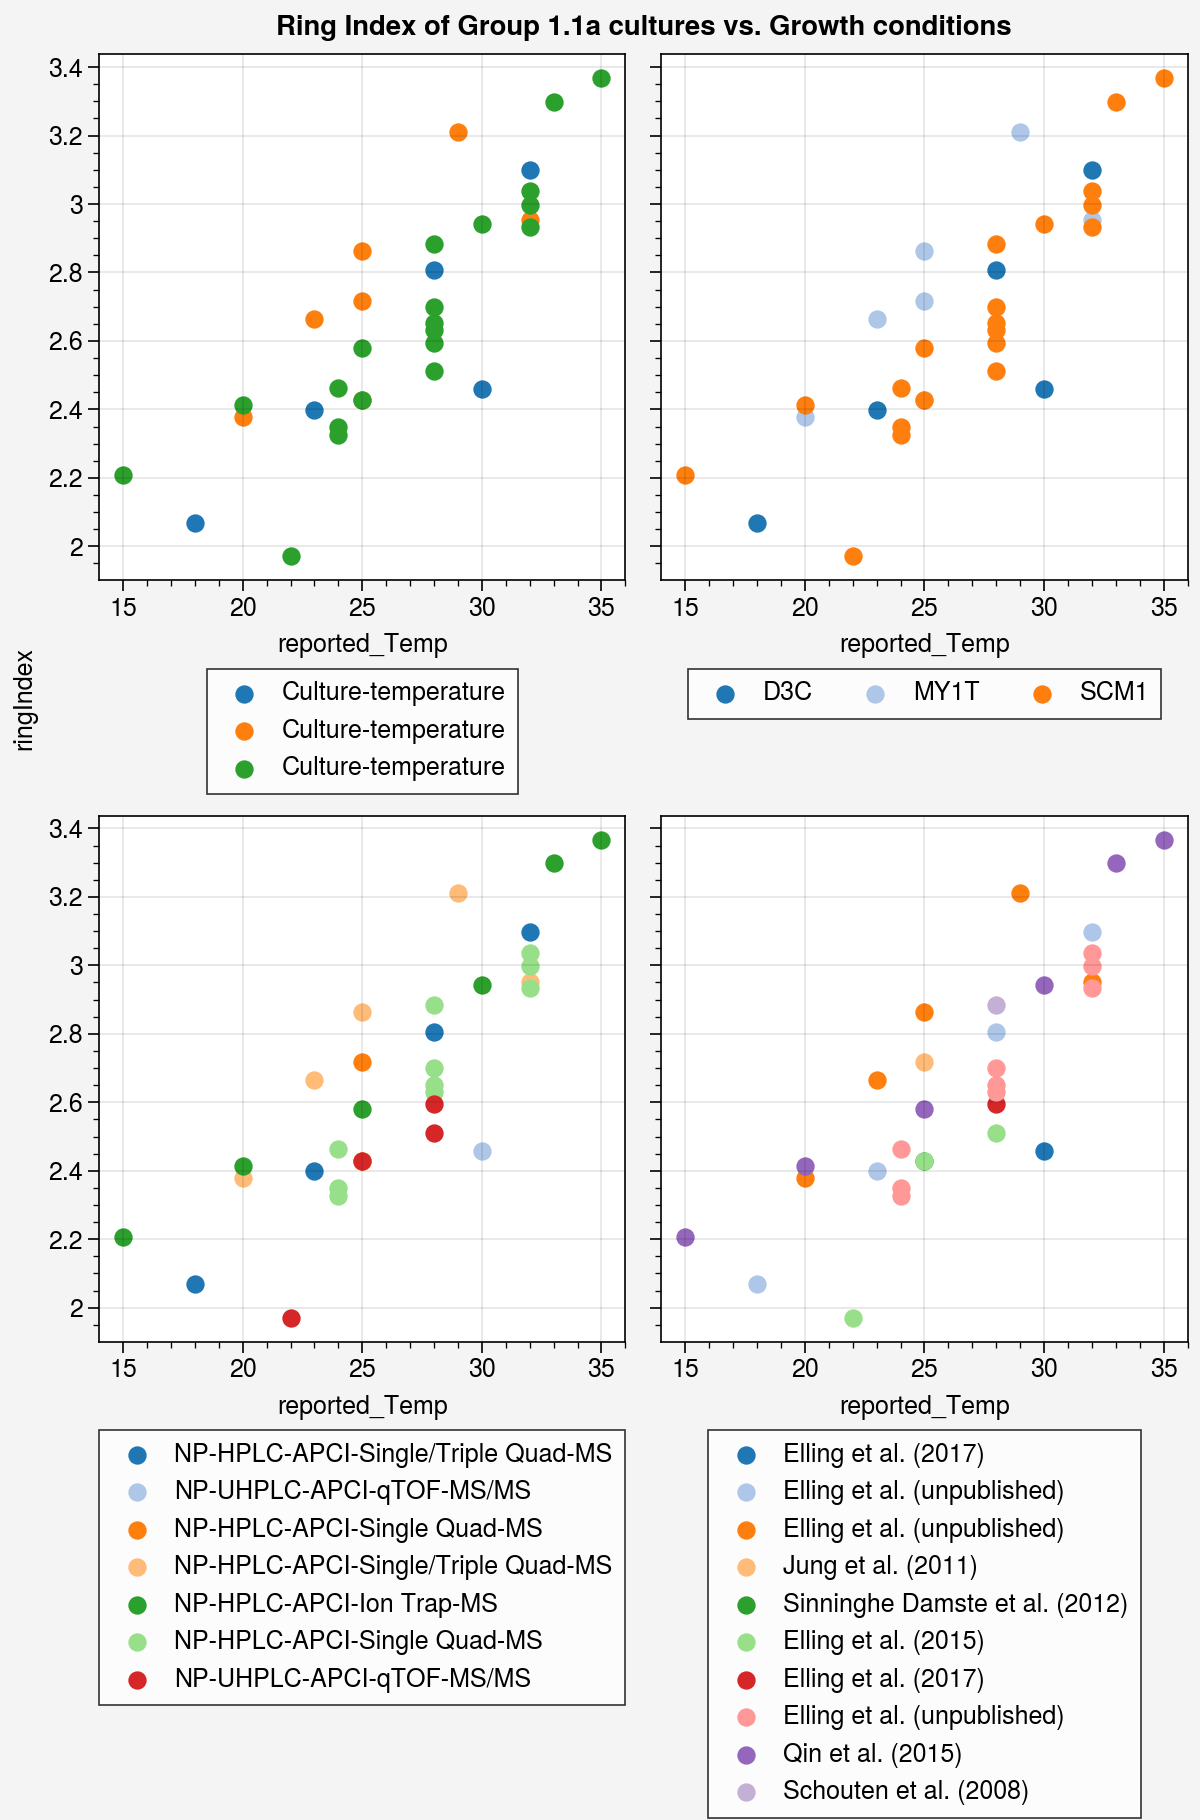

In [11]:

plot_data = culture_df2[culture_df2['GTDB_family'] == 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data = plot_data[plot_data['Source']!='Varma et al. (2024) Biogeosciences']
plot_data = plot_data[plot_data['experiment_setup']=='Culture-temperature']
plot_data2 = plot_data[plot_data['Strains']=='SCM1']
chart_label_name = 'Group 1.1a'
# plot_data = plot_data[plot_data['organism_broadClass2']==chart_label_name]
# plot_data = plot_data[plot_data['Strains']==chart_label_name]

fig, axs = plot.subplots(width=6,ncols=2,nrows=2,sharex=0)
ggrouped2 = plot_data.groupby('Strains')
for key, group2 in ggrouped2:
    if len(group2['LCMS_instrumentation'].unique())==1:
        continue
    else:

        grouped = group2.groupby('experiment_setup')
        for key, group in grouped:
            axs[0].scatter(group['reported_Temp'],group['ringIndex'],
                        cycle='tab10',
                        label=key,marker='o')



            
        


        axs.format(
            suptitle=f'Ring Index of {chart_label_name} cultures vs. Growth conditions',
        )


        # Add arrows and text annotations
        # axs[0].arrow(25.2, 2.4, 5, -0.2, fc='black', ec='black')
        # axs[0].arrow(28.2, 2.5, 2, -0.3, fc='black', ec='black')
        # axs[0].text(30, 2.2, 'QToF-MS\n(Elling15)', fontsize=10, color='black',
        #             ha='left',va='top')

        # axs[0].arrow(28.2, 2.6, 1.8, -0.05, fc='black', ec='black')
        # axs[0].text(30.2, 2.55, 'QToF-MS\n(Elling17)', fontsize=10, color='black',
        #             ha='left',va='top')

        # axs[0].arrow(19.9, 2.42, 0, 0.5, fc='black', ec='black')
        # axs[0].arrow(24.9, 2.62, -5, 0.3, fc='black', ec='black')
        # axs[0].arrow(29.9, 2.95, -10, -0.02, fc='black', ec='black')
        # axs[0].text(25, 3, 'Ion Trap-MS\n(Qin15)', fontsize=10, color='black',
        #             ha='right',va='bottom')

        # axs[0].arrow(28.2, 2.86, 1.8, -0.05, fc='black', ec='black')
        # axs[0].text(30.2, 2.9, 'Ion Trap-MS\n(Schouten07)', fontsize=10, color='black',
        #             ha='left',va='top')

        grouped = group2.groupby('Strains')
        for key, group in grouped:
            axs[1].scatter(group['reported_Temp'],group['ringIndex'],
                        cycle='tab20',
                        label=key,marker='o')
            
        

        grouped = group2.groupby('LCMS_instrumentation')
        for key, group in grouped:
            axs[2].scatter(group['reported_Temp'],group['ringIndex'],
                        cycle='tab20',
                        label=key,marker='o')
            
        

        grouped = group2.groupby('Source2')
        for key, group in grouped:
            axs[3].scatter(group['reported_Temp'],group['ringIndex'],
                        cycle='tab20',
                        label=key,marker='o')

        # axs.scatter(plot_data2['reported_Temp'],plot_data2['ringIndex'],
        #             c='none',edgecolor='black',marker='o',linewidth=1.5,zorder=10,
        #             label='SCM1 cultures')
        
        
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h,l,ncol=1,loc='b',fontsize=10)
        
h, l = axs[1].get_legend_handles_labels()
axs[1].legend(h,l,ncol=3,loc='b',fontsize=10)

h, l = axs[2].get_legend_handles_labels()
axs[2].legend(h,l,ncol=1,loc='b',fontsize=10)

h, l = axs[3].get_legend_handles_labels()
axs[3].legend(h,l,ncol=1,loc='b',fontsize=10)

In [12]:
pd.pivot_table(plot_data,
               index=['Source','LCMS_instrumentation'],
               values=['reported_Temp'],
               aggfunc=['count'],)


count
                                                                                      reported_Temp
Source                                             LCMS_instrumentation                            
Bale et al. (2019) AEM                             NP-HPLC-APCI-Single Quad-MS                    3
Elling et al. (2015) GCA                           NP-UHPLC-APCI-qTOF-MS/MS                      10
Elling et al. (2017) Environmnental Microbiology   NP-UHPLC-APCI-qTOF-MS/MS                       5
Elling et al. Unpublished                          NP-HPLC-APCI-Single Quad-MS                    9
                                                   NP-HPLC-APCI-Single/Triple Quad-MS            13
Jung et al. (2011) AEM                             NP-HPLC-APCI-Single Quad-MS                    1
Jung et al. (2014) AEM                             NP-HPLC-APCI-Single Quad-MS                    1
Pitcher et al. (2011) AEM                          NP-HPLC-APCI-Single Quad-MS                    3
Qin et al. (2015) PNAS                             NP-HPLC-APCI-Ion Trap-MS                      16
Schouten et al. (2008) AEM                         NP-HPLC-APCI-Single Quad-MS                    1
Sinninghe Damste et al. (2002) Journal of Lipid... NP-HPLC-APCI-Single Quad-MS                    1
Sinninghe Damste et al. (2012) AEM                 NP-HPLC-APCI-Single Quad-MS                    2

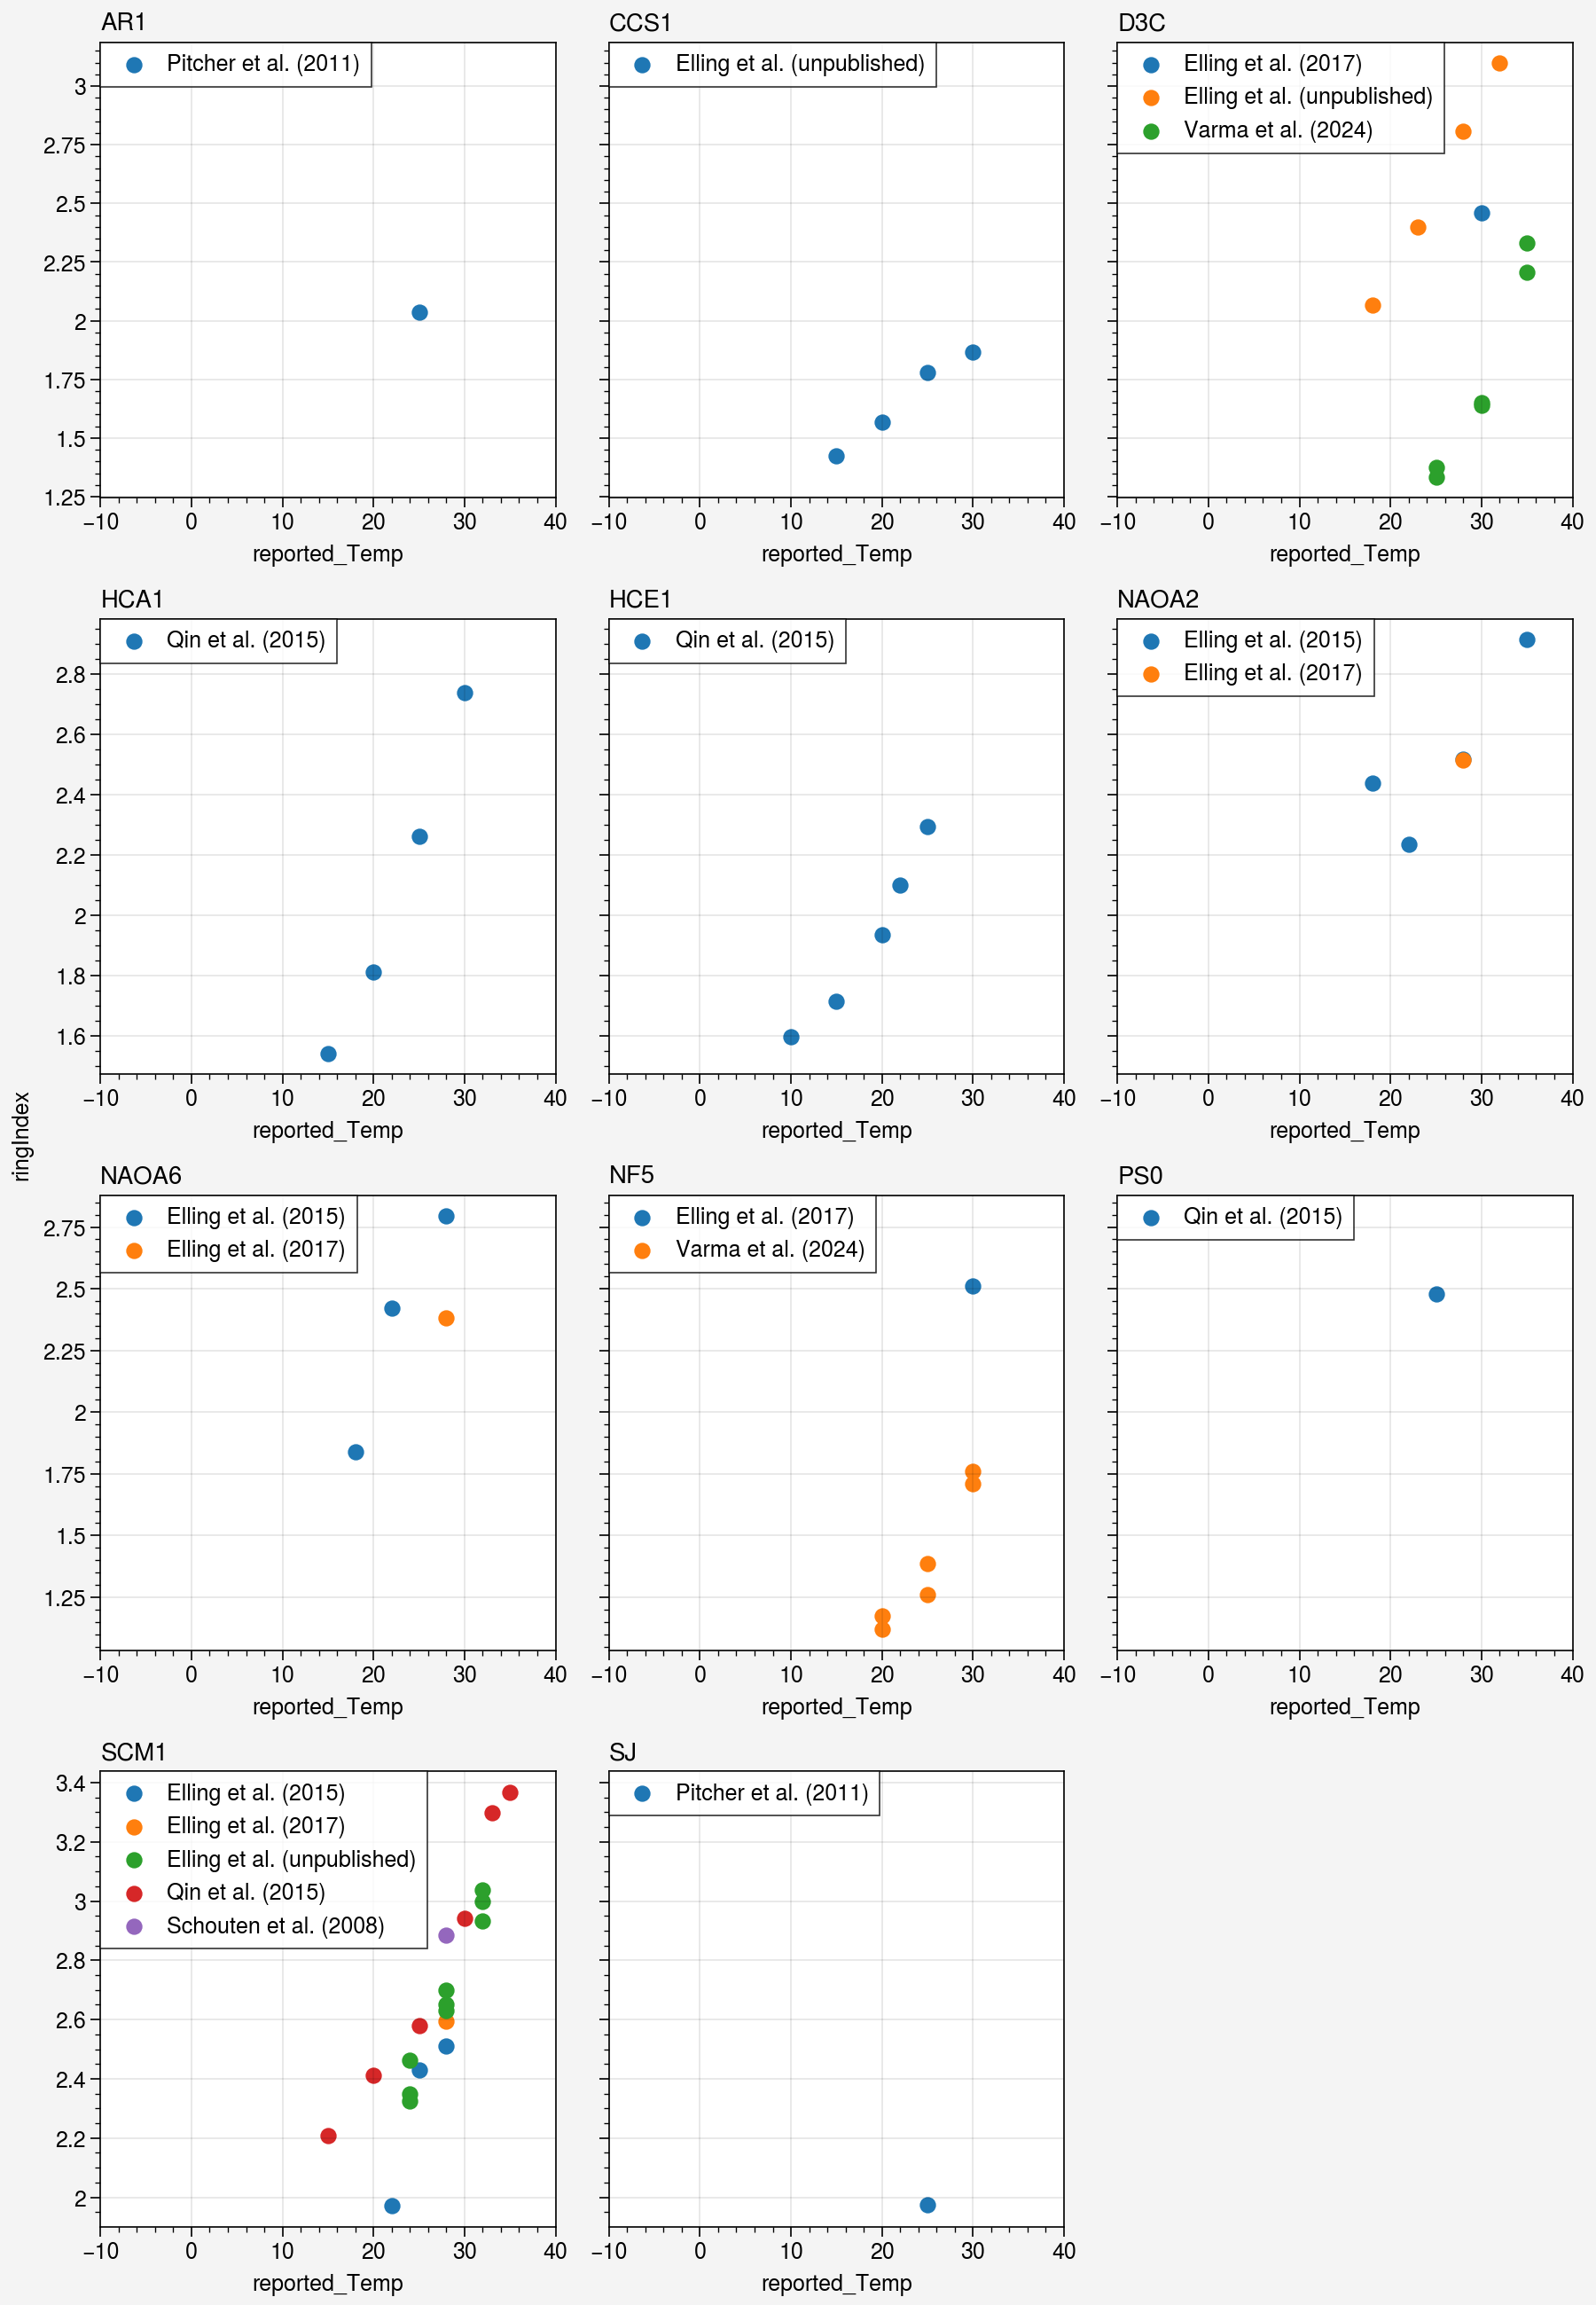

In [13]:
plot_data = culture_df2[culture_df2['GTDB_family'] == 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data = plot_data[plot_data['experiment_setup']=='Culture-temperature']
plot_data = plot_data[plot_data['GTDB_genus']=='g__Nitrosopumilus']



grouped_genus = plot_data.groupby('Strains')
fig, axs = plot.subplots(
    width=9,ncols=3,nrows=4,sharex=0
)

for i, (key, group) in enumerate(grouped_genus):
    axs[i].format(ltitle=key)
    grouped2 = group.groupby('Source2')
    for key2, group2 in grouped2:
        axs[i].scatter(group2['reported_Temp'],group2['ringIndex'],
                       cycle='tab10',
                       label=key2,marker='o')
        
        h, l = axs[i].get_legend_handles_labels()
        axs[i].legend(h,l,ncol=1,loc='ul',fontsize=10)

axs[-1].set_visible(False)



axs.format(
    xlim=(-10,40),
)

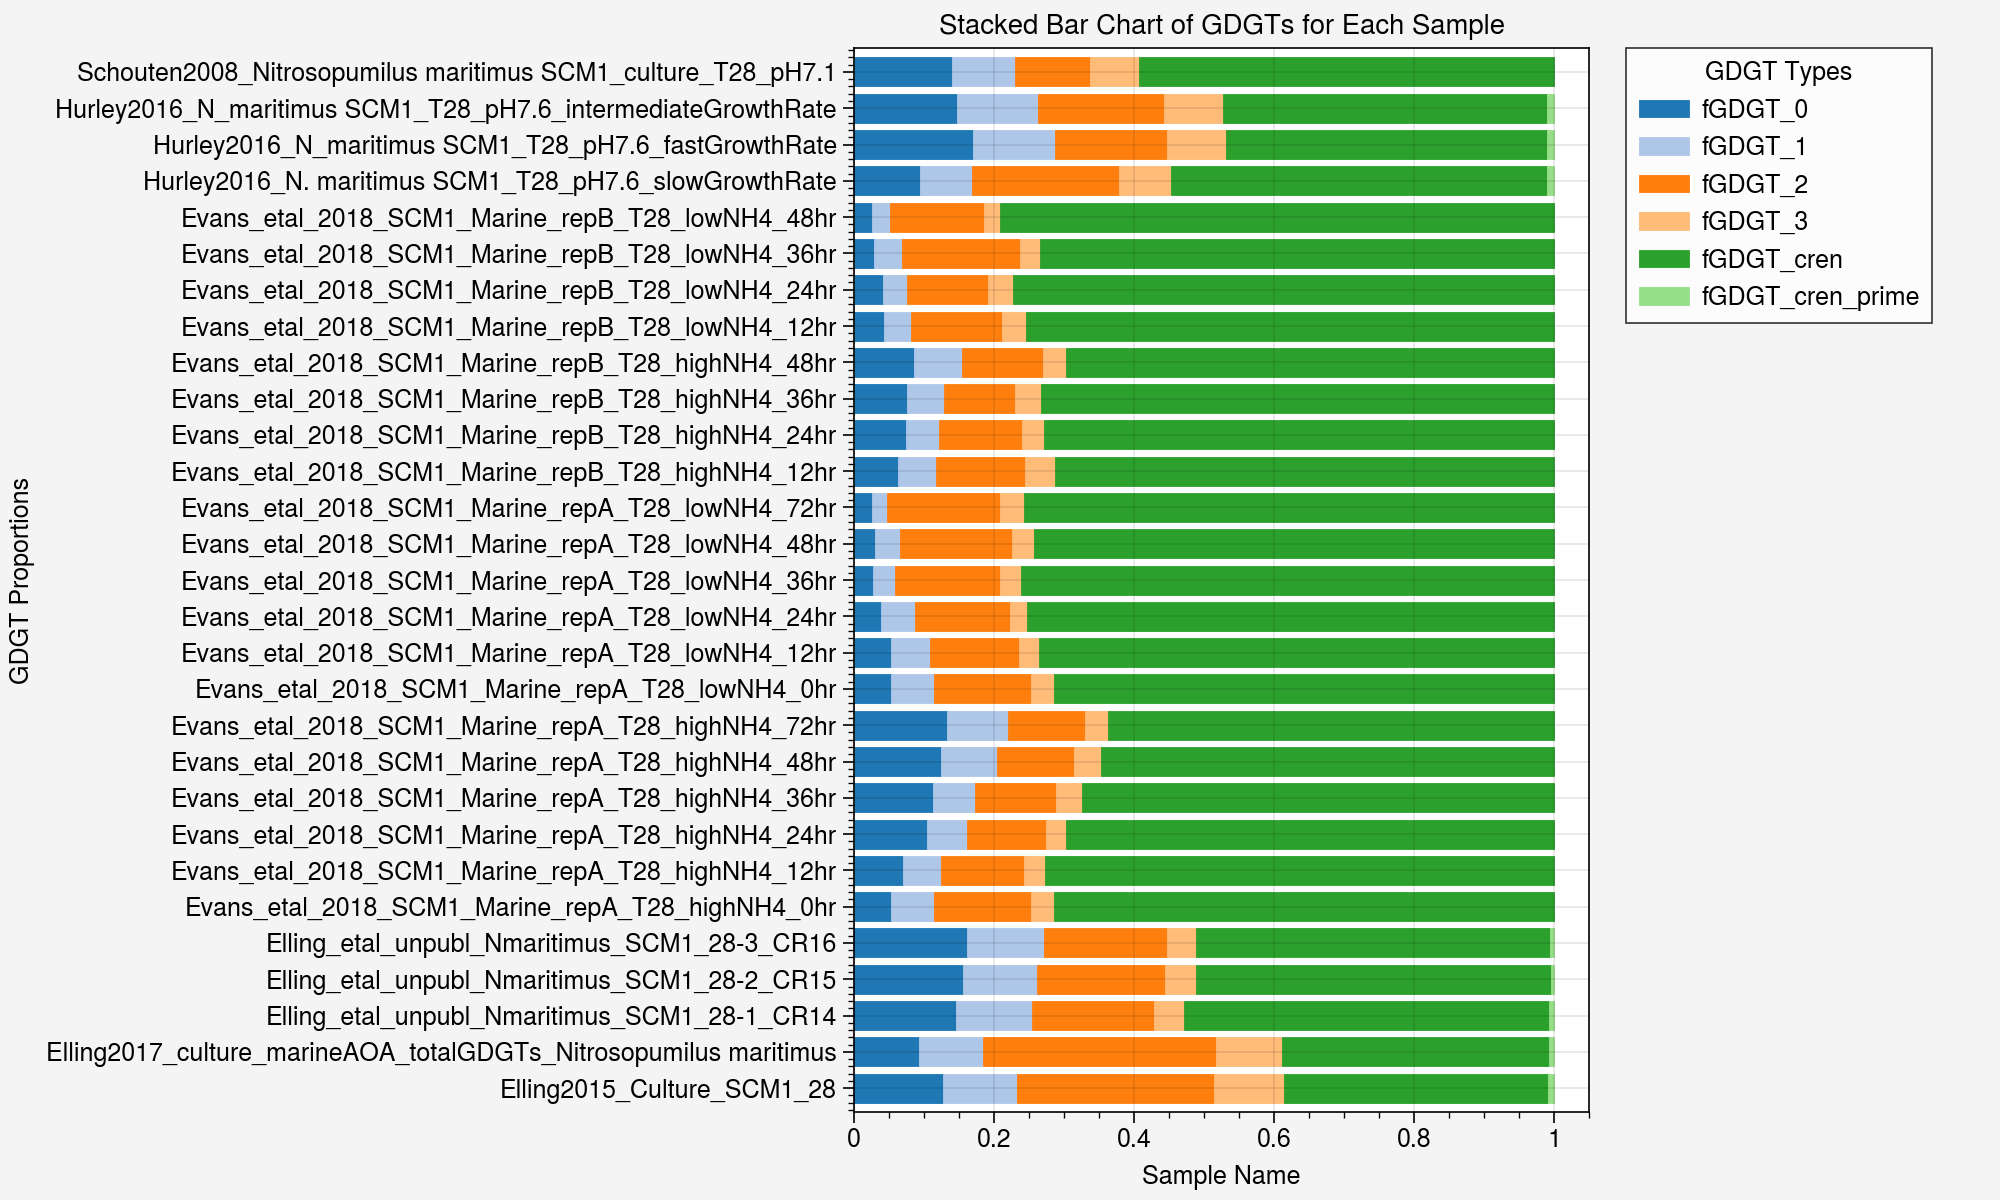

In [14]:
fig, axs = plot.subplots(figsize=(10,6))
plot_data = culture_df2[culture_df2['GTDB_family'] == 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data = plot_data[plot_data['Source']!='Varma et al. (2024) Biogeosciences'][
    plot_data['Strains']=='SCM1'][plot_data['reported_Temp']==28]

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
plot_data_grouped = plot_data.groupby('sampleName')[features].sum()
colors = plot.get_colors('tab20',N=6)
plot_data_grouped.plot(kind='barh', stacked=True,
                       legend=False, width=0.8,
                       color=colors,
                       ax=axs)
axs.set_title('Stacked Bar Chart of GDGTs for Each Sample')
axs.set_xlabel('Sample Name')
axs.set_ylabel('GDGT Proportions')
axs.legend(title='GDGT Types', bbox_to_anchor=(1.05, 1), loc='upper left',ncol=1)
fig.tight_layout()

In [15]:
fpath = os.path.join(local_github_path,'spreadsheets')
fname = r'texmesocosms.csv'
mesocosm_df = pd.read_csv(os.path.join(fpath,fname))

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
17,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.195035,0.060284,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile
18,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.054469,0.019553,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile
19,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.060683,0.018963,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile
20,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.101818,0.172121,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile
21,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.109714,0.266286,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,TEXAS_PSM_culture_RR108,Elling_etal_unpubl_Nmaritimus_SCM1_28-2_CR15,Elling et al. Unpublished,28,0.686003,2.651623,0.662906,4.152970,7.0,p__Thermoproteota,...,0.106074,0.182525,0.043951,0.506893,0.005268,culture,0.393685,0.234510,0,Culture-temperature_Marine mesophile
202,TEXAS_PSM_culture_RR109,Elling_etal_unpubl_Nmaritimus_SCM1_28-3_CR16,Elling et al. Unpublished,28,0.667589,2.630964,0.657741,4.239946,7.0,p__Thermoproteota,...,0.111141,0.175113,0.041301,0.504631,0.006792,culture,0.390421,0.241900,0,Culture-temperature_Marine mesophile
203,TEXAS_PSM_culture_RR110,Elling_etal_unpubl_Nmaritimus_SCM1_32-1_CR17,Elling et al. Unpublished,32,0.778790,2.998250,0.749562,4.437900,7.0,p__Thermoproteota,...,0.069875,0.194540,0.043836,0.594323,0.007624,culture,0.338664,0.131266,0,Culture-temperature_Marine mesophile
204,TEXAS_PSM_culture_RR111,Elling_etal_unpubl_Nmaritimus_SCM1_32-2_CR18,Elling et al. Unpublished,32,0.705434,3.037094,0.759274,3.404992,7.0,p__Thermoproteota,...,0.071250,0.125673,0.036909,0.642895,0.008048,culture,0.264283,0.151988,0,Culture-temperature_Marine mesophile


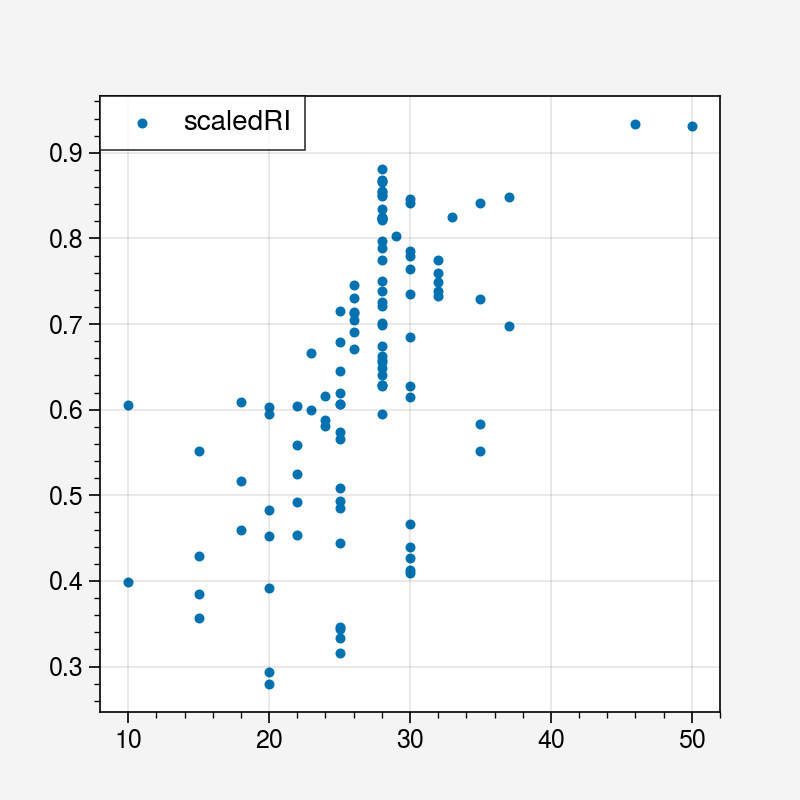

In [16]:
plot_data = culture_df2[culture_df2['GTDB_family'] == 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data_1 = plot_data[['sampleName','Source','reported_Temp','TEX86',
                         'ringIndex','scaledRI','gdgt23ratio','phyloT_order',
                        'GTDB_phylum','NCBI_phylum','GTDB_class','NCBI_class','GTDB_order','NCBI_order',
                        'GTDB_family','NCBI_family','GTDB_genus','NCBI_genus','GTDB_species','NCBI_species',
                        'Strains','experiment_setup','organism_broadClass','organism_broadClass2','organism_broadClass3',
                        'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime'
                        ]].rename(columns={'reported_Temp':'Temperature'})

temp_sampleID = ['TEXAS_PSM_culture_RR'+str(i).zfill(3) for i in range(1,len(plot_data_1)+1)]
plot_data_1.insert(0,'sampleID',temp_sampleID)
plot_data_1['datatype'] = 'culture'
plot_data_1['methaneIndex'] = np.sum(plot_data_1[['fGDGT_1', 'fGDGT_2', 'fGDGT_3']],axis=1)/np.sum(plot_data_1[['fGDGT_1','fGDGT_2','fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime']],axis=1)
plot_data_1['gdgtZeroOverZeroCren'] = plot_data_1['fGDGT_0']/(plot_data_1['fGDGT_0'] + plot_data_1['fGDGT_cren'])
plot_data_1['BIT'] = 0
plot_data_1['violin_bins'] = plot_data_1['experiment_setup']+'_'+plot_data_1['organism_broadClass']

display(plot_data_1)
plt.scatter(plot_data_1['Temperature'],plot_data_1['scaledRI'],marker='.',label=r'scaledRI')
plt.legend(loc='best',fontsize=10)


In [17]:
plot_data_1[plot_data_1['Strains']=='PS0']

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
84,TEXAS_PSM_culture_RR034,Qin2015_017_Nitrosopumilus ureiphilus PS0_Cult...,Qin et al. (2015) PNAS,25,0.378578,2.480200,0.620050,3.021858,4.0,p__Thermoproteota,...,0.125900,0.055300,0.018300,0.544100,0.003100,culture,0.267176,0.317657,0,Culture-temperature_Marine mesophile
90,TEXAS_PSM_culture_RR040,Qin2015_023_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.830204,2.853456,0.713364,8.598726,4.0,p__Thermoproteota,...,0.062419,0.270081,0.031409,0.535461,0.003701,culture,0.402969,0.153274,0,Culture-oxygen_Marine mesophile
91,TEXAS_PSM_culture_RR041,Qin2015_024_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.800980,2.856128,0.714032,7.350575,4.0,p__Thermoproteota,...,0.073137,0.255928,0.034817,0.538069,0.003602,culture,0.401834,0.149320,0,Culture-oxygen_Marine mesophile
92,TEXAS_PSM_culture_RR042,Qin2015_025_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.736403,2.984594,0.746148,6.003268,4.0,p__Thermoproteota,...,0.079032,0.183774,0.030612,0.605142,0.006403,culture,0.324232,0.135734,0,Culture-oxygen_Marine mesophile
93,TEXAS_PSM_culture_RR043,Qin2015_026_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.679259,2.923469,0.730867,5.881041,4.0,p__Thermoproteota,...,0.090036,0.158263,0.026911,0.603541,0.005502,culture,0.311234,0.160918,0,Culture-oxygen_Marine mesophile
94,TEXAS_PSM_culture_RR044,Qin2015_027_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.594332,2.817190,0.704298,5.584071,4.0,p__Thermoproteota,...,0.104563,0.126276,0.022614,0.593756,0.004303,culture,0.297650,0.200054,0,Culture-oxygen_Marine mesophile
95,TEXAS_PSM_culture_RR045,Qin2015_028_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.542880,2.761886,0.690471,4.869369,4.0,p__Thermoproteota,...,0.113102,0.108197,0.022220,0.587529,0.003904,culture,0.291657,0.219311,0,Culture-oxygen_Marine mesophile
96,TEXAS_PSM_culture_RR046,Qin2015_029_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.454837,2.685849,0.671462,3.963918,4.0,p__Thermoproteota,...,0.118995,0.076962,0.019416,0.585769,0.002902,culture,0.267862,0.250672,0,Culture-oxygen_Marine mesophile


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
54,TEXAS_PSM_culture_RR001,Elling2017_culture_ThAOA_totalGDGTs_Nitrosocal...,Elling et al. (2017) Environmnental Microbiology,72,0.612884,3.129260,0.782315,1.885747,25.1,p__Thermoproteota,...,0.050936,0.021266,0.011277,0.702391,0.048099,culture,0.100099,0.191187,0,Culture-temperature_Terrestrial thermophile
55,TEXAS_PSM_culture_RR002,Elling2017_culture_ThAOA_totalGDGTs_Nitrososph...,Elling et al. (2017) Environmnental Microbiology,35,0.920575,3.640753,0.910188,0.907867,15.0,p__Thermoproteota,...,0.034385,0.040728,0.044861,0.534625,0.312957,culture,0.123998,0.057212,0,Culture-temperature_Terrestrial thermophile
56,TEXAS_PSM_culture_RR003,Elling2017_culture_ThAOA_totalGDGTs_Nitrososph...,Elling et al. (2017) Environmnental Microbiology,46,0.966310,3.894759,0.973690,0.299016,15.0,p__Thermoproteota,...,0.011710,0.002984,0.009978,0.638877,0.322909,culture,0.025011,0.020756,0,Culture-temperature_Terrestrial thermophile
57,TEXAS_PSM_culture_RR004,Pearson2008_027_Pure Cultures-Acidilobus sacch...,Pearson et al. (2008) Applied and Environmenta...,82,1.000000,3.000000,0.750000,0.000000,21.0,p__Thermoproteota,...,0.000000,0.000000,1.000000,0.000000,0.000000,culture,1.000000,NaN,0,Culture-temperature_Terrestrial thermoacidophile
58,TEXAS_PSM_culture_RR005,Pearson2008_028_Pure Cultures-Metallosphaera s...,Pearson et al. (2008) Applied and Environmenta...,75,0.761905,1.942857,0.485714,0.920000,18.0,p__Thermoproteota,...,0.214286,0.328571,0.357143,0.000000,0.000000,culture,1.000000,1.000000,0,Culture-temperature_Terrestrial thermoacidophile
59,TEXAS_PSM_culture_RR006,Pearson2008_029_Pure Cultures-Sulfolobus solfa...,Pearson et al. (2008) Applied and Environmenta...,85,0.947368,2.684211,0.671053,0.285714,19.0,p__Thermoproteota,...,0.052632,0.210526,0.736842,0.000000,0.000000,culture,1.000000,NaN,0,Culture-temperature_Terrestrial thermoacidophile
60,TEXAS_PSM_culture_RR007,Pearson2008_030_Pure Cultures-Vulcanisaeta mou...,Pearson et al. (2008) Applied and Environmenta...,85,0.869565,2.111111,0.527778,0.428571,23.0,p__Thermoproteota,...,0.111111,0.222222,0.518519,0.000000,0.000000,culture,1.000000,1.000000,0,Culture-temperature_Terrestrial hyperthermophilic
61,TEXAS_PSM_culture_RR008,Pearson2008_034_Pure Cultures-Thermoproteus uz...,Pearson et al. (2008) Applied and Environmenta...,85,0.875000,1.809524,0.452381,0.750000,22.0,p__Thermoproteota,...,0.095238,0.285714,0.380952,0.000000,0.000000,culture,1.000000,1.000000,0,Culture-temperature_Terrestrial thermoacidophile
62,TEXAS_PSM_culture_RR009,Pearson2008_032_Pure Cultures-Desulfurococcus ...,Pearson et al. (2008) Applied and Environmenta...,85,0.830508,2.029412,0.507353,0.633333,20.0,p__Thermoproteota,...,0.147059,0.279412,0.441176,0.000000,0.000000,culture,1.000000,1.000000,0,Culture-temperature_Terrestrial hyperthermophilic
63,TEXAS_PSM_culture_RR010,Pearson2008_033_Pure Cultures-Desulfurococcus ...,Pearson et al. (2008) Applied and Environmenta...,85,0.837838,1.955556,0.488889,0.550000,20.0,p__Thermoproteota,...,0.133333,0.244444,0.444444,0.000000,0.000000,culture,1.000000,1.000000,0,Culture-temperature_Terrestrial hyperthermophilic


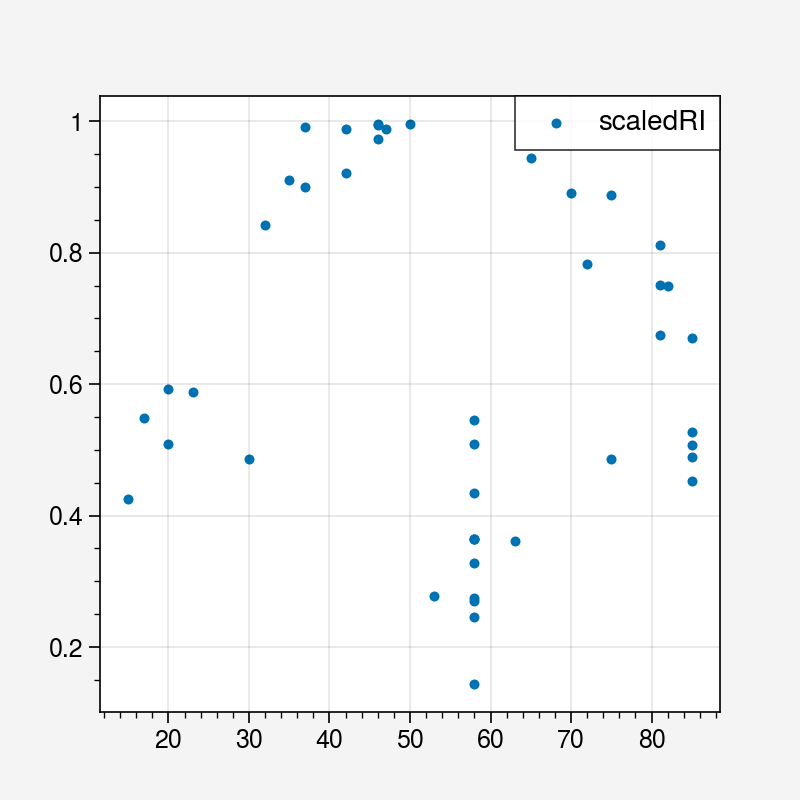

In [18]:
plot_data = culture_df2[culture_df2['GTDB_family'] != 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data_2 = plot_data[['sampleName','Source','reported_Temp','TEX86',
                         'ringIndex','scaledRI','gdgt23ratio','phyloT_order',
                        'GTDB_phylum','NCBI_phylum','GTDB_class','NCBI_class','GTDB_order','NCBI_order',
                        'GTDB_family','NCBI_family','GTDB_genus','NCBI_genus','GTDB_species','NCBI_species',
                        'Strains','experiment_setup','organism_broadClass','organism_broadClass2','organism_broadClass3',
                        'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime'
                        ]].rename(columns={'reported_Temp':'Temperature'})

temp_sampleID = ['TEXAS_PSM_culture_RR'+str(i).zfill(3) for i in range(1,len(plot_data_2)+1)]
plot_data_2.insert(0,'sampleID',temp_sampleID)
plot_data_2['datatype'] = 'culture'
plot_data_2['methaneIndex'] = np.sum(plot_data_2[['fGDGT_1', 'fGDGT_2', 'fGDGT_3']],axis=1)/np.sum(plot_data_2[['fGDGT_1','fGDGT_2','fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime']],axis=1)
plot_data_2['gdgtZeroOverZeroCren'] = plot_data_2['fGDGT_0']/(plot_data_2['fGDGT_0'] + plot_data_2['fGDGT_cren'])
plot_data_2['BIT'] = 0
plot_data_2['violin_bins'] = plot_data_2['experiment_setup']+'_'+plot_data_2['organism_broadClass']

display(plot_data_2)
plt.scatter(plot_data_2['Temperature'],plot_data_2['scaledRI'],marker='.',label=r'scaledRI')
plt.legend(loc='best',fontsize=10)


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,fGDGT_0,fGDGT_1,...,NCBI_family,GTDB_genus,NCBI_genus,GTDB_species,NCBI_species,Strains,experiment_setup,organism_broadClass,organism_broadClass2,organism_broadClass3
0,TEXAS_PSM_mesocosm_RR001,meso_001,Wuchter2004,10,0.334578,1.967739,0.491935,2.685656,0.416348,0.096573,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
1,TEXAS_PSM_mesocosm_RR002,meso_002,Wuchter2004,15,0.288381,1.939119,0.484780,2.190909,0.434734,0.088906,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
2,TEXAS_PSM_mesocosm_RR003,meso_003,Wuchter2004,15,0.239814,1.856318,0.464080,2.250000,0.451412,0.097281,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
3,TEXAS_PSM_mesocosm_RR004,meso_004,Wuchter2004,22,0.466403,2.991935,0.747984,2.858779,0.196237,0.051843,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
4,TEXAS_PSM_mesocosm_RR005,meso_005,Wuchter2004,25,0.461538,3.058343,0.764586,1.763466,0.193623,0.040726,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
5,TEXAS_PSM_mesocosm_RR006,meso_006,Wuchter2004,25,0.483547,3.228140,0.807035,3.037383,0.145988,0.043298,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
6,TEXAS_PSM_mesocosm_RR007,meso_007,Wuchter2004,30,0.527554,3.043329,0.760832,4.415385,0.153019,0.071979,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
7,TEXAS_PSM_mesocosm_RR008,meso_008,Wuchter2004,35,0.705459,3.162726,0.790682,5.052474,0.108380,0.057469,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
8,TEXAS_PSM_mesocosm_RR009,meso_009,Wuchter2004,13,0.263181,1.874010,0.468502,2.705674,0.480893,0.057159,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
9,TEXAS_PSM_mesocosm_RR010,meso_010,Wuchter2004,15,0.309940,2.180438,0.545109,2.971429,0.371221,0.090714,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm


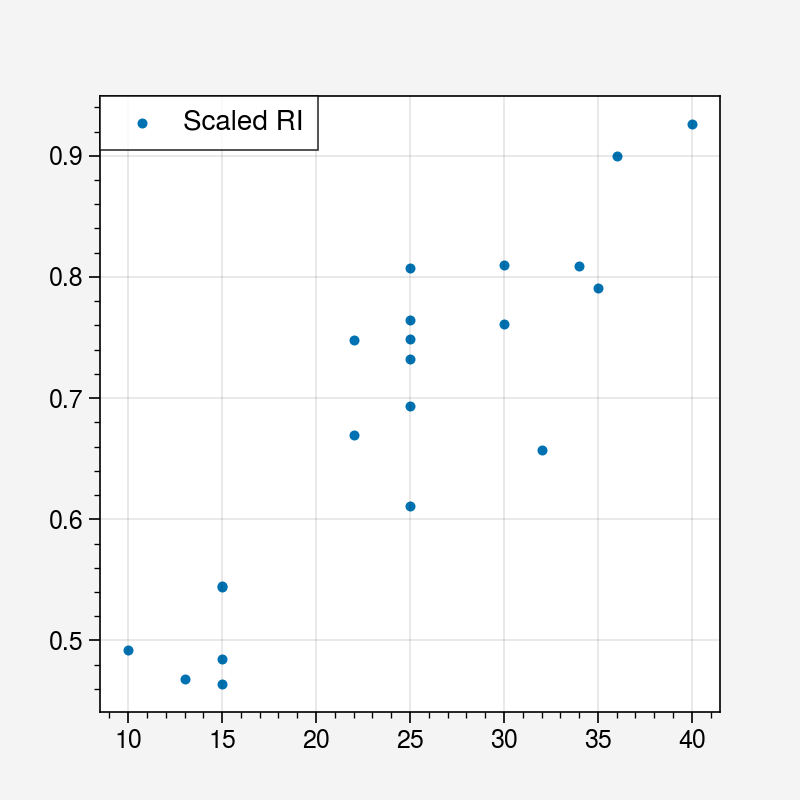

In [19]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
mesocosm_df['ringIndex'] = np.array([mesocosm_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
mesocosm_df['scaledRI'] = mesocosm_df['ringIndex']/4
mesocosm_df['gdgt23ratio'] = mesocosm_df['fGDGT_2']/mesocosm_df['fGDGT_3']
mesocosm_df['sampleName'] = ['meso_'+f'{i+1}'.zfill(3) for i in range(len(mesocosm_df))]
plot_data_3 = mesocosm_df[['sampleName','Source','Temperature','tex86',
                           'ringIndex','scaledRI','gdgt23ratio',   
                           'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
                           'fGDGT_cren', 'fGDGT_cren_prime']].rename(columns={
                                                                        'tex86':'TEX86',
                                                                        })

temp_sampleID = ['TEXAS_PSM_mesocosm_RR'+str(i).zfill(3) for i in range(1,len(plot_data_3)+1)]
plot_data_3.insert(0,'sampleID',temp_sampleID)
plot_data_3['datatype'] = 'mesocosm'
plot_data_3['methaneIndex'] = np.sum(plot_data_3[['fGDGT_1','fGDGT_2','fGDGT_3']],axis=1)/np.sum(plot_data_3[['fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']],axis=1)
plot_data_3['gdgtZeroOverZeroCren'] = plot_data_3['fGDGT_0']/(plot_data_3['fGDGT_0'] + plot_data_3['fGDGT_cren'])
plot_data_3['BIT'] = 0
plot_data_3['phyloT_order'] = 0
new_cols = [
    'GTDB_phylum','NCBI_phylum','GTDB_class','GTDB_family',
    'NCBI_class','GTDB_order','NCBI_order','NCBI_family',
    'GTDB_genus','NCBI_genus','GTDB_species','NCBI_species',
    'Strains','experiment_setup',
    'organism_broadClass','organism_broadClass2','organism_broadClass3']
for col in new_cols:
    plot_data_3[col] = 'mesocosm'
    

display(plot_data_3)
plt.scatter(plot_data_3['Temperature'],plot_data_3['scaledRI'],marker='.',label=r'Scaled RI')
plt.legend(loc='upper left',fontsize=10)

In [20]:
merged_df = pd.concat([plot_data_1,plot_data_2,plot_data_3],axis=0)
display(merged_df)

fpath = os.path.join(local_github_path,'spreadsheets')
fname = r'culture_mesocosm_combined_rev_030425.csv'
merged_df.to_csv(os.path.join(fpath,fname),index=False)

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
17,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.195035,0.060284,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile
18,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.054469,0.019553,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile
19,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.060683,0.018963,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile
20,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.101818,0.172121,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile
21,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.109714,0.266286,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.073897,0.035219,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN
17,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.051583,0.055801,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN
18,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.049939,0.045612,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN
19,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.023916,0.054250,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN


#  3. Build a WOA both hemisphere (BH) seasonal data

In [21]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/seasonal'
fname = r'woa23_decav91C0_t*.nc'

T_season_da = xr.open_mfdataset(os.path.join(fpath,fname),combine='by_coords',decode_times=False,).t_an
T_season_da
### change the time coordinate to season and idx as "win", "spr", "sum", "aut"
seasons = ['win', 'spr', 'sum', 'aut']
T_season_da = T_season_da.assign_coords(time=('time', seasons))
T_season_da

<xarray.DataArray 't_an' (time: 4, depth: 102, lat: 720, lon: 1440)>
dask.array<concatenate, shape=(4, 102, 720, 1440), dtype=float32, chunksize=(1, 102, 720, 1440), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * time     (time) <U3 'win' 'spr' 'sum' 'aut'
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [22]:
# your original
# T_season_da: dims = (time:4, depth:102, lat:720, lon:1440)
seasons = ['win','spr','sum','aut']

# mapping NH season → SH “local” season
opp = dict(zip(seasons, seasons[2:] + seasons[:2]))
#   {'win':'sum', 'spr':'aut', 'sum':'win', 'aut':'spr'}

pieces = []
for s in seasons:
    # NH view
    nh = T_season_da.sel(time=s)
    # SH view: pick the opposite label
    sh = T_season_da.sel(time=opp[s])
    # merge NH vs SH by latitude
    merged = xr.where(
        T_season_da.lat >= 0,   # condition broadcast over depth×lat×lon
        nh,                     # where True (NH)
        sh                      # where False (SH)
    )
    # give it back the time coordinate = s
    pieces.append(merged.expand_dims(time=[s]) )

# stitch back into one DataArray
bhsea_T_da = xr.concat(pieces, dim='time')

# check your new coord
bhsea_T_da

# fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/seasonal'
# fname = r'bh_seasonal_T.nc'
# bhsea_T_da.to_netcdf(os.path.join(fpath,fname),mode='w',format='NETCDF4',engine='netcdf4')

<xarray.DataArray (time: 4, lat: 720, depth: 102, lon: 1440)>
dask.array<concatenate, shape=(4, 720, 102, 1440), dtype=float32, chunksize=(1, 720, 102, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) <U3 'win' 'spr' 'sum' 'aut'
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03

In [23]:
thermo_depth_list = []
thermo_temp_list  = []

for t in bhsea_T_da.time:
    # ── 1) load this time‐slice (depth,lat,lon)
    slab = (
        bhsea_T_da
          .sel(time=t)
          .isel(depth=slice(0,1100))
          .load()
    )
    t_val = t.values

    # ── 2) compute |dT/dz|
    grad = slab.diff('depth') / slab.depth.diff('depth')
    grad = np.abs(grad)
    grad = grad.where(~np.isnan(slab), drop=False).fillna(-np.inf)

    # ── 3) find thermocline index (+1), mask all‐NaN
    idx0 = (grad.argmax('depth', skipna=True) + 1)
    idx0 = idx0.where(~np.isnan(slab).all('depth'))

    # ── 4) turn that into a pure‐NumPy int array (lat×lon)
    idx0_int = idx0.fillna(0).astype(int).values  # shape (nlat,nlon)

    # ── 5) extract depth via NumPy
    depth_vals   = slab.depth.values              # shape (ndepth,)
    depth_at_idx = depth_vals[idx0_int]           # shape (nlat,nlon)

    da_depth = xr.DataArray(
        depth_at_idx[np.newaxis, ...],
        dims=("time","lat","lon"),
        coords={"time":[t_val], "lat":slab.lat, "lon":slab.lon},
        name="thermocline_depth"
    )

    # ── 6) extract temperature via take_along_axis
    #     first make sure your slab is (depth,lat,lon)
    slab_np = slab.transpose("depth","lat","lon").values      # shape (ndepth,nlat,nlon)

    #     now idx0_int[None,...] is shape (1,nlat,nlon),
    #     so take_along_axis returns shape (1,nlat,nlon)
    temp_at_idx = np.take_along_axis(slab_np, idx0_int[None, ...], axis=0)[0]

    da_temp = xr.DataArray(
        temp_at_idx[np.newaxis, ...],
        dims=("time","lat","lon"),
        coords={"time":[t_val], "lat":slab.lat, "lon":slab.lon},
        name=slab.name
    )

    thermo_depth_list.append(da_depth)
    thermo_temp_list.append(da_temp)

# ── 7) stitch back together along time


thermoT_depth_da = xr.concat(thermo_depth_list, dim="time")  # dims: time,lat,lon
thermoT_da       = xr.concat(thermo_temp_list,  dim="time")

land_mask = ~np.isnan(bhsea_T_da.isel(time=0,depth=0))
thermoT_depth_da = thermoT_depth_da.where(land_mask)
thermoT_da = thermoT_da.where(land_mask)


In [29]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/seasonal'
fname = r'thermocline_depthIntegral_bhsea_T.nc'
thermoT_da.to_netcdf(
    os.path.join(fpath,fname),
    mode='w', format='NETCDF4', engine='netcdf4'
)

In [31]:
## load ds06_calculated_ocean_properties.nc from /nc_files

fpath = f'{local_github_path}/nc_files'
fname = r'ds06_calculated_ocean_properties.nc'
calculated_ocean_properties_ds = xr.open_dataset(os.path.join(fpath,fname))
calculated_ocean_properties_ds



<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [34]:
thermoT_da.sel(time=sea)

<xarray.DataArray (lat: 720, lon: 1440)>
dask.array<getitem, shape=(720, 1440), dtype=float32, chunksize=(720, 1440), chunktype=numpy.ndarray>
Coordinates:
    time     <U3 'win'
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
    depth    float32 0.0

In [36]:
seasons = ['win', 'spr', 'sum', 'aut']

for sea in seasons:
    # select the 2D slice at that season
    T_season       = thermoT_da.sel(time=sea)
    T_depth_season = thermoT_depth_da.sel(time=sea)

    # assign into your Dataset, giving the dims for the 2D array
    calculated_ocean_properties_ds[f't_sf2tc_{sea}'] = (
        ('lat','lon'),
        T_season.values
    )
    calculated_ocean_properties_ds[f'tc_depth_{sea}'] = (
        ('lat','lon'),
        T_depth_season.values
    )

calculated_ocean_properties_ds = calculated_ocean_properties_ds.drop_vars(['time','depth'])

fpath = f'{local_github_path}/nc_files'
fname = r'calculated_ocean_properties_seasonal.nc'
calculated_ocean_properties_ds.to_netcdf(
    os.path.join(fpath,fname),
    mode='w', format='NETCDF4', engine='netcdf4'
)


In [ ]:
fname = r'ds04_gridded_coretop_tex_scaledRI.nc'
gridded_coretop_ds = xr.open_dataset(os.path.join(fpath,fname))
gridded_coretop_ds

<xarray.Dataset>
Dimensions:                (lat: 720, lon: 1440)
Coordinates:
  * lat                    (lat) float32 -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                    (lon) float32 -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables: (12/14)
    region_ID              (lon, lat) float64 ...
    tex_count              (lon, lat) float64 ...
    tex_median             (lon, lat) float64 ...
    tex_mean               (lon, lat) float64 ...
    tex_std                (lon, lat) float64 ...
    scaledRI_count         (lon, lat) float64 ...
    ...                     ...
    scaledRI_std           (lon, lat) float64 ...
    gdgt23ratio_count      (lon, lat) float64 ...
    gdgt23ratio_median     (lon, lat) float64 ...
    gdgt23ratio_mean       (lon, lat) float64 ...
    gdgt23ratio_std        (lon, lat) float64 ...
    modernWaterDepth_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [42]:
calculated_ocean_properties_ds[f't_sf2tc_{sea}']

<xarray.DataArray 't_sf2tc_win' (lat: 720, lon: 1440)>
array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [-0.46181002, -0.46291003, -0.46401   , ..., -0.45891002,
        -0.45981002, -0.46081   ],
       [-0.46531   , -0.46581   , -0.46641   , ..., -0.46361002,
        -0.46421   , -0.46471003],
       [-0.46461   , -0.46461   , -0.46461   , ..., -0.46461   ,
        -0.46461   , -0.46461   ]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9

In [49]:
sel_T[nonnan_idx]

<xarray.DataArray 't_sf2tc_win' (lat: 1514, lon: 1514)>
array([[-1.6436    ,         nan,         nan, ...,         nan,
                nan,         nan],
       [-1.68491   , -1.8107101 , -1.87571   , ...,         nan,
                nan,         nan],
       [-1.4709    , -0.83841   , -1.8794    , ...,         nan,
                nan,         nan],
       ...,
       [-1.52411   , -0.33901   , -0.81851   , ..., -0.31561002,
         0.2028    , -0.1745    ],
       [-1.63071   , -1.13231   ,  0.47248998, ..., -0.80491   ,
         0.10309   , -0.1427    ],
       [-1.6393    , -0.56281   , -1.64361   , ..., -0.56721   ,
         0.2184    , -0.73731   ]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -77.88 -77.38 -77.12 -76.62 ... 86.88 87.12 88.62
  * lon      (lon) float32 -40.38 -158.4 -45.38 -35.38 ... -146.1 104.6 153.6

In [71]:
sel_TEX[nonnan_idx].to_dataframe().reset_index()['tex_median'].dropna()

0          0.41365
363        0.41365
386        0.41365
392        0.41365
394        0.41365
            ...   
2289165    0.43800
2289649    0.50000
2290680    0.50000
2291948    0.50100
2292195    0.50100
Name: tex_median, Length: 21469, dtype: float64

In [67]:
for sea in seasons:
    sel_T = calculated_ocean_properties_ds[f't_sf2tc_{sea}']
    sel_TEX = gridded_coretop_ds[f'tex_median'].T

    nonnan_idx = np.where(~np.isnan(sel_TEX) & ~np.isnan(sel_T))

    sel_T2 = sel_T[nonnan_idx].to_dataframe().reset_index().dropna()['t_sf2tc_win']
    sel_TEX2 = sel_TEX[nonnan_idx].to_dataframe().reset_index().dropna()['tex_median']
    
    xx = sel_T2
    yy = sel_TEX2

    ## spearmanr, pval
    rho, pval = spearmanr(xx, yy)
    print(rho, pval)
    print(f'Season: {sea}, Spearman correlation: {rho:.3f}, p-value: {pval:.3f}')

ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 1482653 and the array at index 1 has size 21469